# Projet 7 — CIFAR-10 Classical ML Pipeline (SVM / KNN / Random Forest)

Pipeline: loading -> HSV -> HOG -> HSV hist -> LBP -> concat -> standardization -> PCA -> SVM/KNN/RF -> evaluation.
Dataset: CIFAR-10, official split (50k train / 10k test), SEED=42.


In [5]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn scikit-image tqdm tensorflow


Note: you may need to restart the kernel to use updated packages.


In [6]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.colors as mcolors

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray

from tensorflow.keras.datasets import cifar10

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")


## 1) Dataset Loading & Preprocessing


Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)
Classes: 10
Train counts: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]
Test counts : [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


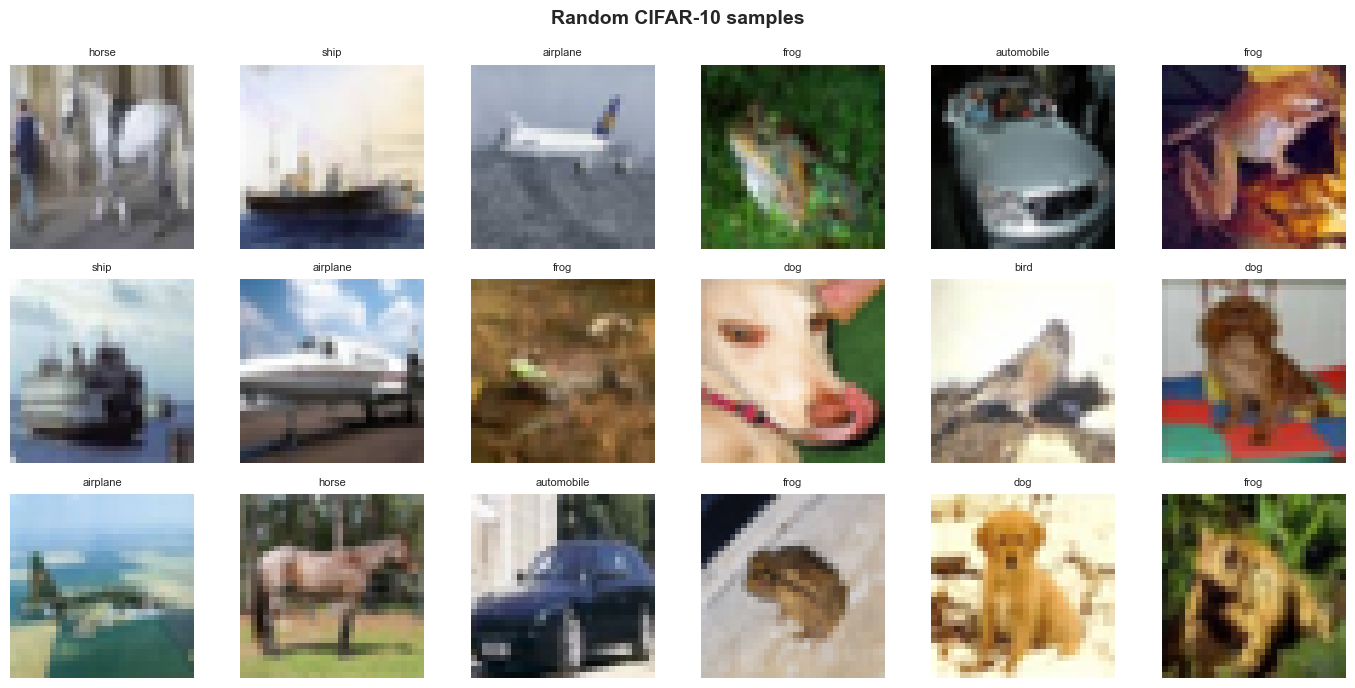

In [7]:
(X_train_raw, y_train), (X_test_raw, y_test) = cifar10.load_data()
y_train = y_train.ravel()
y_test = y_test.ravel()

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print("Train:", X_train_raw.shape, y_train.shape)
print("Test :", X_test_raw.shape, y_test.shape)
print("Classes:", len(class_names))
print("Train counts:", np.bincount(y_train, minlength=10))
print("Test counts :", np.bincount(y_test, minlength=10))

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
idx = np.random.choice(len(X_train_raw), size=18, replace=False)
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(X_train_raw[i]); ax.set_title(class_names[y_train[i]], fontsize=8); ax.axis("off")
plt.suptitle("Random CIFAR-10 samples", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


## 2) HSV Conversion


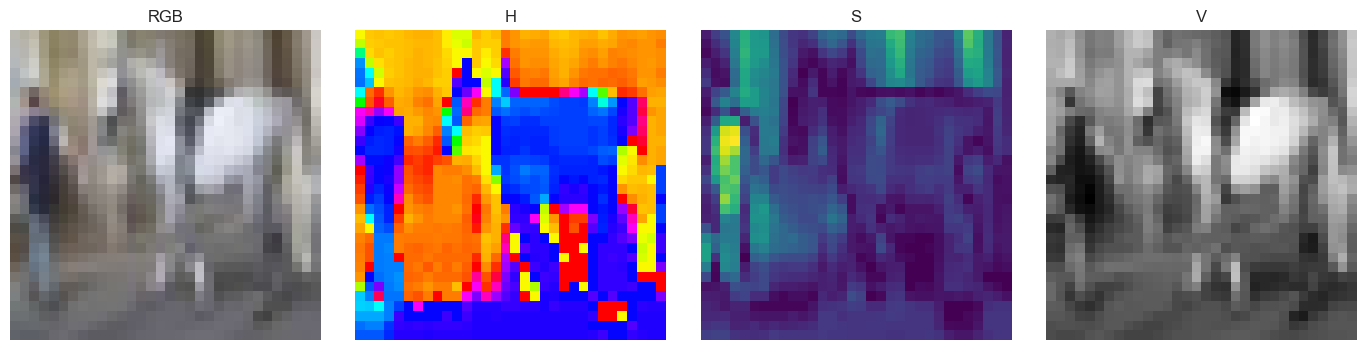

In [8]:
def rgb_to_hsv_np(img_uint8):
    return mcolors.rgb_to_hsv(img_uint8.astype(np.float32) / 255.0)

X_train_hsv = np.stack([rgb_to_hsv_np(x) for x in X_train_raw])
X_test_hsv = np.stack([rgb_to_hsv_np(x) for x in X_test_raw])

sample_i = int(idx[0])
rgb = X_train_raw[sample_i]
hsv = X_train_hsv[sample_i]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(rgb); axes[0].set_title("RGB"); axes[0].axis("off")
axes[1].imshow(hsv[..., 0], cmap="hsv"); axes[1].set_title("H"); axes[1].axis("off")
axes[2].imshow(hsv[..., 1], cmap="viridis"); axes[2].set_title("S"); axes[2].axis("off")
axes[3].imshow(hsv[..., 2], cmap="gray"); axes[3].set_title("V"); axes[3].axis("off")
plt.tight_layout(); plt.show()


## 3) HOG Extraction


HOG:   0%|          | 0/50000 [00:00<?, ?it/s]

HOG:   0%|          | 0/10000 [00:00<?, ?it/s]

HOG train: (50000, 324) | HOG test: (10000, 324)


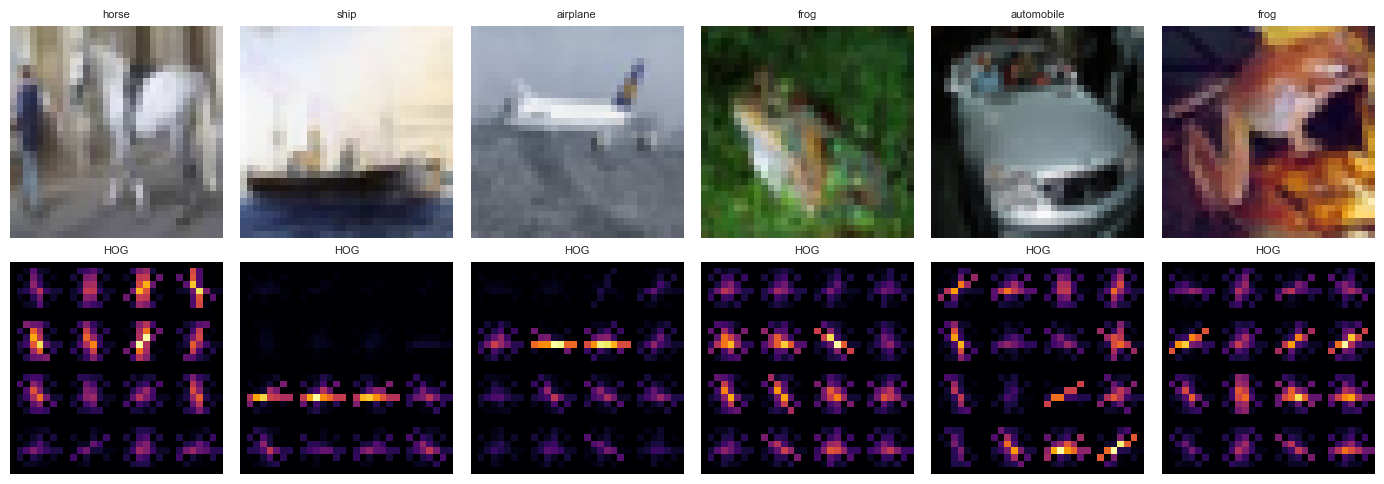

In [9]:
def extract_hog_batch(X_rgb):
    feats, vis = [], []
    for img in tqdm(X_rgb, desc="HOG", leave=False):
        gray = (rgb2gray(img) * 255).astype(np.uint8)
        f, h = hog(gray, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2),
                   block_norm='L2-Hys', transform_sqrt=True, feature_vector=True, visualize=True)
        feats.append(f.astype(np.float32)); vis.append(h.astype(np.float32))
    return np.stack(feats), np.stack(vis)

X_train_hog, X_train_hog_vis = extract_hog_batch(X_train_raw)
X_test_hog, _ = extract_hog_batch(X_test_raw)
print("HOG train:", X_train_hog.shape, "| HOG test:", X_test_hog.shape)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, i in zip(axes[0], idx[:6]):
    ax.imshow(X_train_raw[i]); ax.axis("off"); ax.set_title(class_names[y_train[i]], fontsize=8)
for ax, i in zip(axes[1], idx[:6]):
    ax.imshow(X_train_hog_vis[i], cmap="inferno"); ax.axis("off"); ax.set_title("HOG", fontsize=8)
plt.tight_layout(); plt.show()


## 4) Color Histogram (HSV, H and S only)


HSV hist train: (50000, 64) | test: (10000, 64)


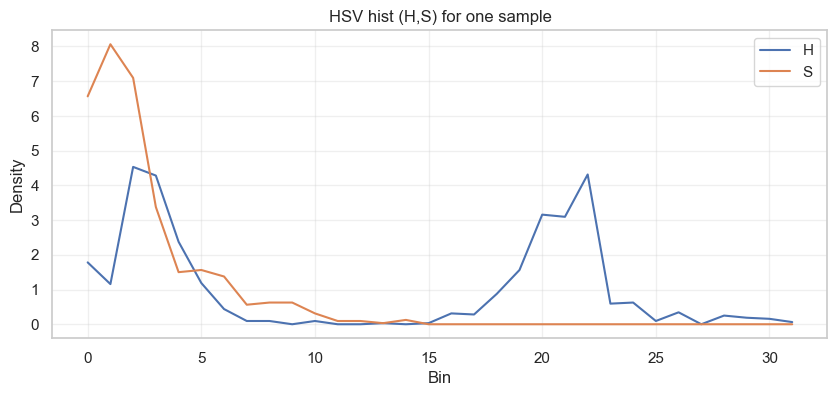

In [10]:
def extract_hsv_hist_batch(X_hsv, bins=32):
    feats = []
    for img in X_hsv:
        h0, _ = np.histogram(img[..., 0], bins=bins, range=(0,1), density=True)
        h1, _ = np.histogram(img[..., 1], bins=bins, range=(0,1), density=True)
        feats.append(np.concatenate([h0, h1]).astype(np.float32))
    return np.stack(feats)

X_train_hsv_hist = extract_hsv_hist_batch(X_train_hsv, bins=32)
X_test_hsv_hist = extract_hsv_hist_batch(X_test_hsv, bins=32)
print("HSV hist train:", X_train_hsv_hist.shape, "| test:", X_test_hsv_hist.shape)

s = X_train_hsv_hist[sample_i]
bins = 32
plt.figure(figsize=(10, 4))
plt.plot(s[:bins], label="H"); plt.plot(s[bins:], label="S")
plt.title("HSV hist (H,S) for one sample"); plt.xlabel("Bin"); plt.ylabel("Density")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 5) LBP Extraction (spatial 4x4 grid)


LBP:   0%|          | 0/50000 [00:00<?, ?it/s]

c:\Users\FERRA\.conda\envs\dl\lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


LBP:   0%|          | 0/10000 [00:00<?, ?it/s]

LBP train: (50000, 416) | test: (10000, 416)


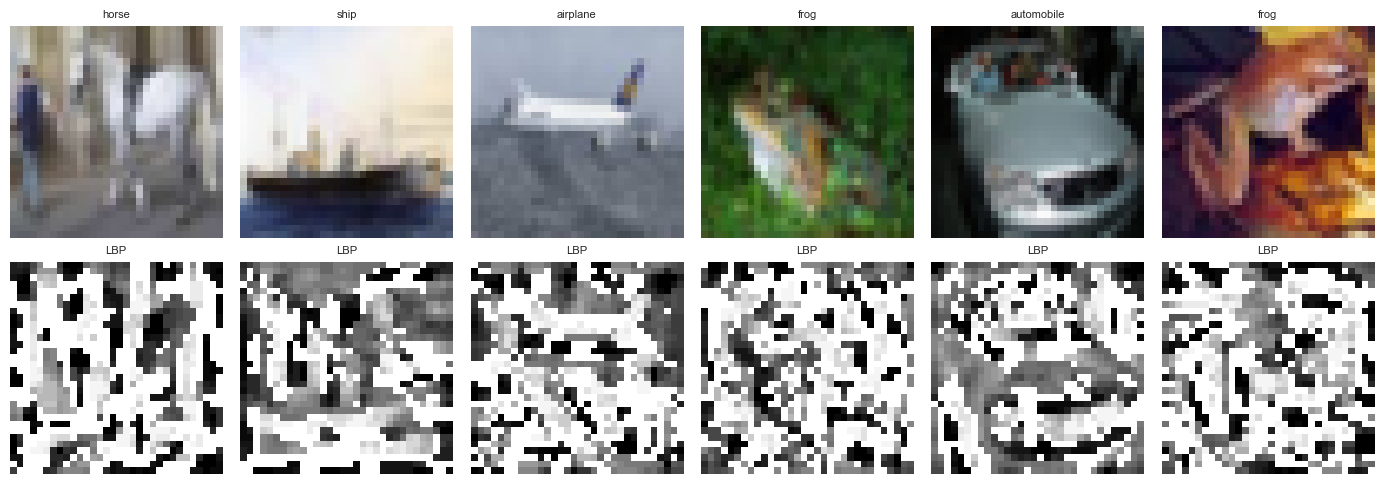

In [11]:
def extract_lbp_batch(X_rgb, P=24, R=3, grid=4):
    feats = []
    n_bins = P + 2
    for img in tqdm(X_rgb, desc="LBP", leave=False):
        gray = rgb2gray(img)
        gh, gw = gray.shape[0] // grid, gray.shape[1] // grid
        hist_all = []
        for r in range(grid):
            for c in range(grid):
                patch = gray[r*gh:(r+1)*gh, c*gw:(c+1)*gw]
                lbp = local_binary_pattern(patch, P=P, R=R, method='uniform')
                hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
                hist_all.append(hist.astype(np.float32))
        feats.append(np.concatenate(hist_all))
    return np.stack(feats)

X_train_lbp = extract_lbp_batch(X_train_raw, P=24, R=3, grid=4)
X_test_lbp = extract_lbp_batch(X_test_raw, P=24, R=3, grid=4)
print("LBP train:", X_train_lbp.shape, "| test:", X_test_lbp.shape)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, i in zip(axes[0], idx[:6]):
    ax.imshow(X_train_raw[i]); ax.axis("off"); ax.set_title(class_names[y_train[i]], fontsize=8)
for ax, i in zip(axes[1], idx[:6]):
    lbp_vis = local_binary_pattern(rgb2gray(X_train_raw[i]), P=24, R=3, method='uniform')
    ax.imshow(lbp_vis, cmap="gray"); ax.axis("off"); ax.set_title("LBP", fontsize=8)
plt.tight_layout(); plt.show()


## 6) Feature Concatenation


In [12]:
X_train_feat = np.hstack([X_train_hog, X_train_hsv_hist, X_train_lbp]).astype(np.float32)
X_test_feat = np.hstack([X_test_hog, X_test_hsv_hist, X_test_lbp]).astype(np.float32)
print("HOG dims:", X_train_hog.shape[1], "| HSV dims:", X_train_hsv_hist.shape[1], "| LBP dims:", X_train_lbp.shape[1], "| Total dims:", X_train_feat.shape[1])
print(f"Final Feature Vector = [HOG | Color Hist | LBP] = {X_train_feat.shape[1]} dims")


HOG dims: 324 | HSV dims: 64 | LBP dims: 416 | Total dims: 804
Final Feature Vector = [HOG | Color Hist | LBP] = 804 dims


## 7) Standardization


Mean first 5: [-0. -0.  0.  0.  0.]
Std first 5 : [1. 1. 1. 1. 1.]


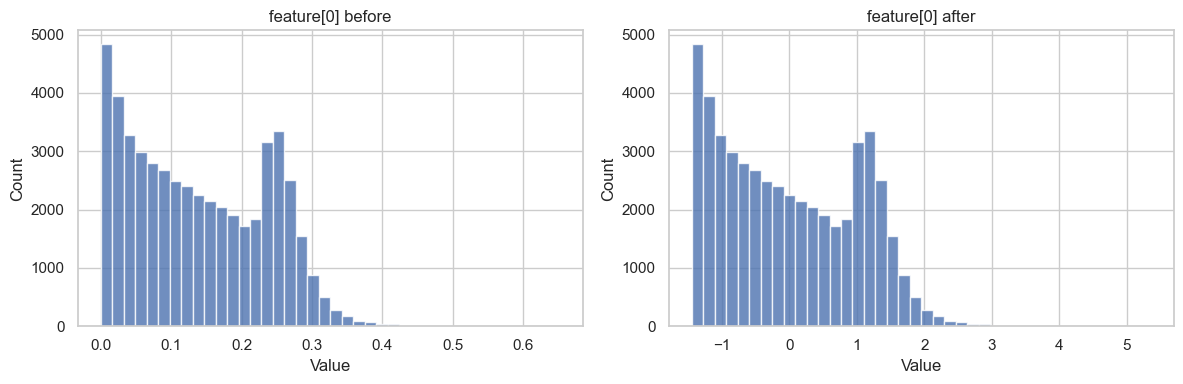

In [13]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_feat)
X_test_std = scaler.transform(X_test_feat)
print("Mean first 5:", np.round(X_train_std[:, :5].mean(axis=0), 4))
print("Std first 5 :", np.round(X_train_std[:, :5].std(axis=0), 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train_feat[:, 0], bins=40, alpha=0.8); axes[0].set_title("feature[0] before")
axes[1].hist(X_train_std[:, 0], bins=40, alpha=0.8); axes[1].set_title("feature[0] after")
for ax in axes:
    ax.set_xlabel("Value"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()


## 8) PCA


PCA: 496 components -> 0.950 variance


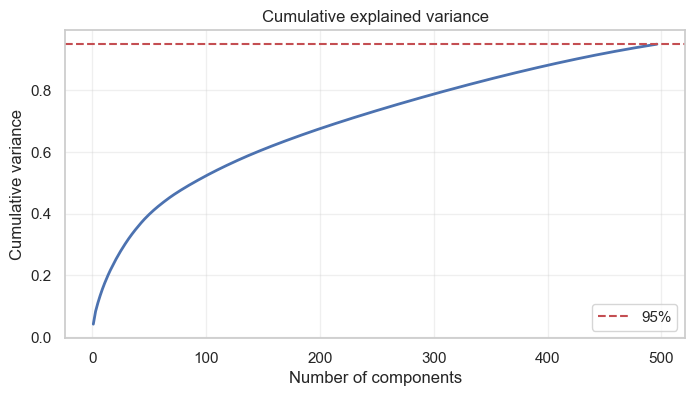

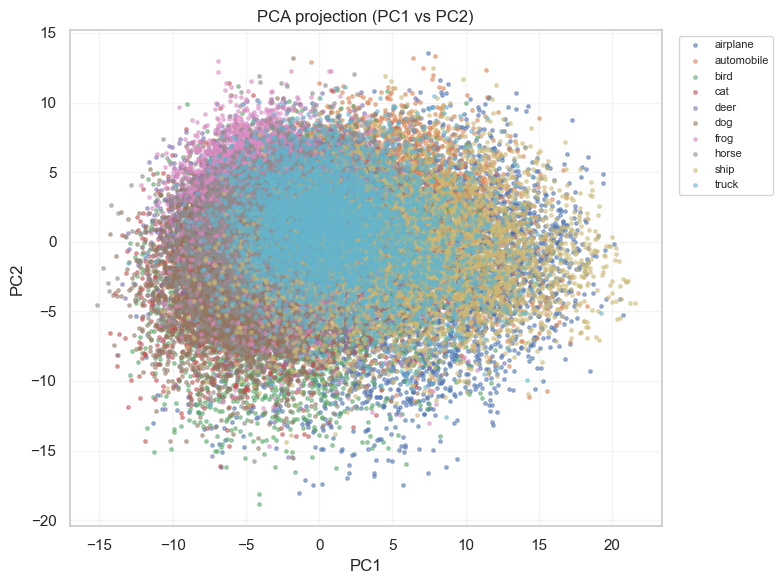

In [14]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)
print(f"PCA: {pca.n_components_} components -> {pca.explained_variance_ratio_.sum():.3f} variance")

cum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(cum)+1), cum, lw=2)
plt.axhline(0.95, color="r", ls="--", label="95%")
plt.title("Cumulative explained variance"); plt.xlabel("Number of components"); plt.ylabel("Cumulative variance")
plt.legend(); plt.grid(alpha=0.3); plt.show()

plt.figure(figsize=(8, 6))
for c in range(10):
    m = y_train == c
    plt.scatter(X_train_pca[m, 0], X_train_pca[m, 1], s=6, alpha=0.5, label=class_names[c])
plt.title("PCA projection (PC1 vs PC2)"); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.grid(alpha=0.2); plt.tight_layout(); plt.show()


## 9) SVM Training & Tuning


### Effet de `C` et `gamma` dans le SVM-RBF

Le paramètre `C` contrôle la régularisation du SVM. Une petite valeur de `C` autorise plus d’erreurs et produit une frontière plus simple, alors qu’une grande valeur de `C` cherche à mieux séparer les données d’entraînement, avec un risque plus élevé de surapprentissage.

Le paramètre `gamma` contrôle l’influence locale des points dans le noyau RBF. Une petite valeur donne une frontière plus lisse et globale, tandis qu’une grande valeur rend la frontière plus complexe et plus sensible aux détails locaux.


Dans ce notebook, plusieurs valeurs de `C` (`0.1` et `10`) et de `gamma` (`0.01`, `0.05`, `0.1`, `scale`) sont testées, puis la meilleure combinaison est choisie selon l’accuracy obtenue.

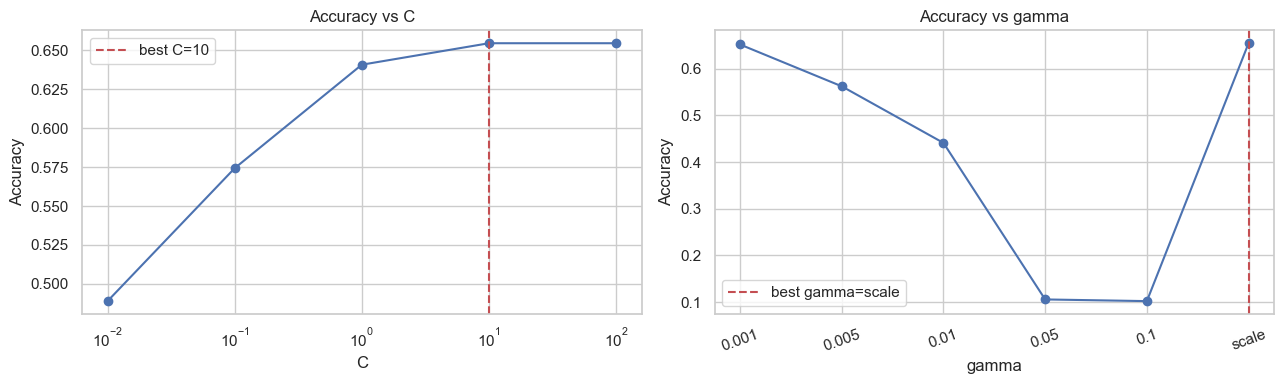

              precision    recall  f1-score   support

    airplane     0.6614    0.7480    0.7020      1000
  automobile     0.7660    0.7890    0.7773      1000
        bird     0.5722    0.5110    0.5399      1000
         cat     0.4838    0.4790    0.4814      1000
        deer     0.5868    0.5980    0.5924      1000
         dog     0.5490    0.5600    0.5545      1000
        frog     0.7188    0.7130    0.7159      1000
       horse     0.7175    0.6730    0.6945      1000
        ship     0.7316    0.7250    0.7283      1000
       truck     0.7530    0.7500    0.7515      1000

    accuracy                         0.6546     10000
   macro avg     0.6540    0.6546    0.6538     10000
weighted avg     0.6540    0.6546    0.6538     10000



In [ ]:
C_values = [1, 10]
acc_c = []
for C in C_values:
    m = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    m.fit(X_train_pca, y_train)
    acc_c.append(accuracy_score(y_test, m.predict(X_test_pca)))
best_c = C_values[int(np.argmax(acc_c))]

gamma_values = [0.001 , 0.005, 0.01, 0.05, 0.1, 'scale']
acc_g = []
for g in gamma_values:
    m = SVC(kernel='rbf', C=10, gamma=g, random_state=42)
    m.fit(X_train_pca, y_train)
    acc_g.append(accuracy_score(y_test, m.predict(X_test_pca)))
best_gamma = gamma_values[int(np.argmax(acc_g))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(C_values, acc_c, marker='o'); axes[0].set_xscale('log')
axes[0].axvline(best_c, color='r', ls='--', label=f'best C={best_c}')
axes[0].set_title('Accuracy vs C'); axes[0].set_xlabel('C'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
xg = np.arange(len(gamma_values))
axes[1].plot(xg, acc_g, marker='o'); axes[1].set_xticks(xg); axes[1].set_xticklabels([str(v) for v in gamma_values], rotation=20)
axes[1].axvline(np.argmax(acc_g), color='r', ls='--', label=f'best gamma={best_gamma}')
axes[1].set_title('Accuracy vs gamma'); axes[1].set_xlabel('gamma'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
t0 = time.time(); svm_model.fit(X_train_pca, y_train); svm_fit_time = time.time() - t0
t1 = time.time(); y_pred_svm = svm_model.predict(X_test_pca); svm_pred_time = time.time() - t1
print(classification_report(y_test, y_pred_svm, target_names=class_names, digits=4))


## 10) KNN Training & Tuning


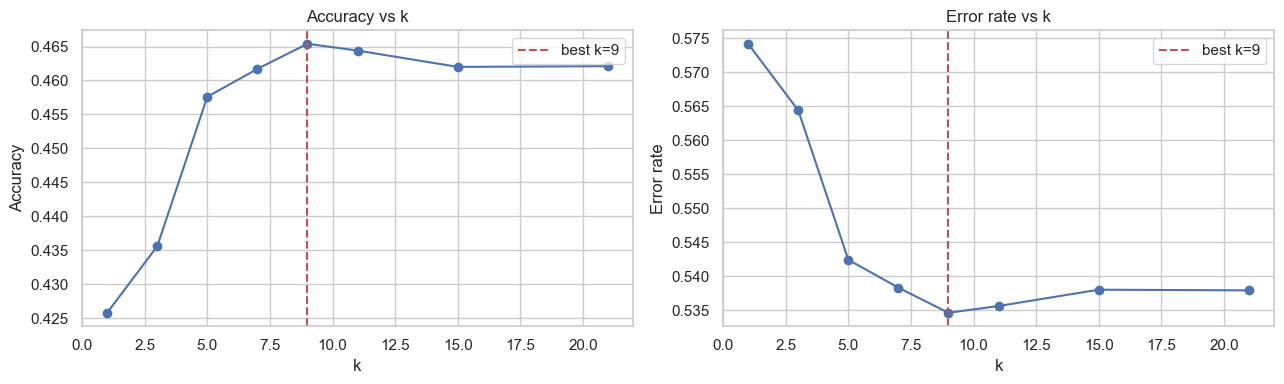

              precision    recall  f1-score   support

    airplane     0.7085    0.4690    0.5644      1000
  automobile     0.7101    0.5610    0.6268      1000
        bird     0.5064    0.2380    0.3238      1000
         cat     0.3955    0.1740    0.2417      1000
        deer     0.2952    0.4360    0.3520      1000
         dog     0.4932    0.2520    0.3336      1000
        frog     0.2870    0.8540    0.4296      1000
       horse     0.6095    0.4370    0.5090      1000
        ship     0.6138    0.6310    0.6223      1000
       truck     0.6082    0.5650    0.5858      1000

    accuracy                         0.4617     10000
   macro avg     0.5227    0.4617    0.4589     10000
weighted avg     0.5227    0.4617    0.4589     10000



In [23]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
accuracies, errors = [], []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean', algorithm='ball_tree')
    knn.fit(X_train_pca, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_pca))
    accuracies.append(acc); errors.append(1 - acc)
best_k = k_values[int(np.argmax(accuracies))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_values, accuracies, marker='o'); axes[0].axvline(best_k, color='r', ls='--', label=f'best k={best_k}')
axes[0].set_title('Accuracy vs k'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].plot(k_values, errors, marker='o'); axes[1].axvline(best_k, color='r', ls='--', label=f'best k={best_k}')
axes[1].set_title('Error rate vs k'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Error rate'); axes[1].legend()
plt.tight_layout(); plt.show()

knn_model = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean', algorithm='ball_tree')
t0 = time.time(); knn_model.fit(X_train_pca, y_train); knn_fit_time = time.time() - t0
t1 = time.time(); y_pred_knn = knn_model.predict(X_test_pca); knn_pred_time = time.time() - t1
print(classification_report(y_test, y_pred_knn, target_names=class_names, digits=4))


## 11) Random Forest Training & Tuning


c:\Users\FERRA\.conda\envs\dl\lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\FERRA\.conda\envs\dl\lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


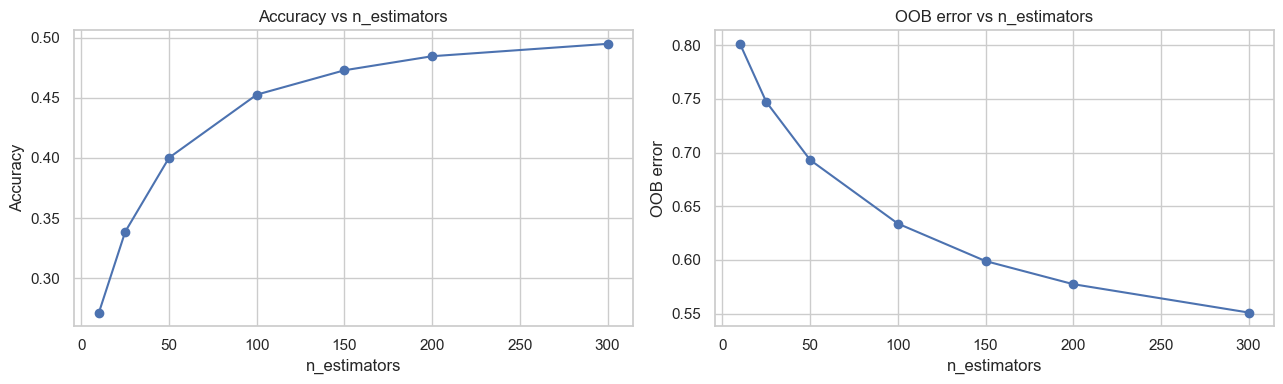

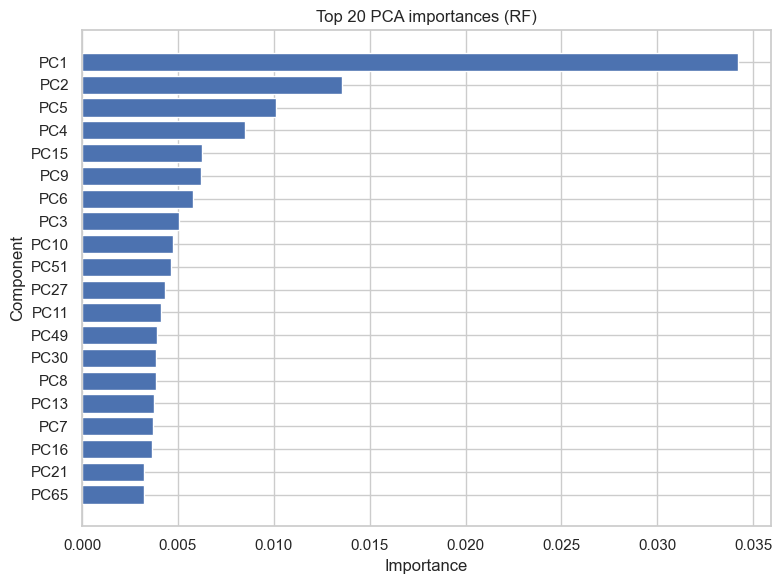

              precision    recall  f1-score   support

    airplane     0.5459    0.5710    0.5582      1000
  automobile     0.5876    0.6540    0.6190      1000
        bird     0.4489    0.2940    0.3553      1000
         cat     0.3284    0.2420    0.2786      1000
        deer     0.4362    0.4170    0.4264      1000
         dog     0.3715    0.4670    0.4138      1000
        frog     0.5027    0.6570    0.5696      1000
       horse     0.5821    0.4820    0.5274      1000
        ship     0.5267    0.6210    0.5700      1000
       truck     0.5911    0.5450    0.5671      1000

    accuracy                         0.4950     10000
   macro avg     0.4921    0.4950    0.4885     10000
weighted avg     0.4921    0.4950    0.4885     10000

OOB score = 0.4489


In [24]:
n_trees_list = [10, 25, 50, 100, 150, 200, 300]
rf_accuracies, oob_errors = [], []
for n in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n, max_features='sqrt', oob_score=True, n_jobs=-1, random_state=42)
    rf.fit(X_train_pca, y_train)
    rf_accuracies.append(accuracy_score(y_test, rf.predict(X_test_pca)))
    oob_errors.append(1 - rf.oob_score_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(n_trees_list, rf_accuracies, marker='o')
axes[0].set_title('Accuracy vs n_estimators'); axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('Accuracy')
axes[1].plot(n_trees_list, oob_errors, marker='o')
axes[1].set_title('OOB error vs n_estimators'); axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('OOB error')
plt.tight_layout(); plt.show()

rf_final = RandomForestClassifier(n_estimators=300, max_features='sqrt', oob_score=True, n_jobs=-1, random_state=42)
t0 = time.time(); rf_final.fit(X_train_pca, y_train); rf_fit_time = time.time() - t0
t1 = time.time(); y_pred_rf = rf_final.predict(X_test_pca); rf_pred_time = time.time() - t1

imp = rf_final.feature_importances_
top_idx = np.argsort(imp)[-20:][::-1]
plt.figure(figsize=(8, 6))
plt.barh([f'PC{i+1}' for i in top_idx][::-1], imp[top_idx][::-1])
plt.title('Top 20 PCA importances (RF)'); plt.xlabel('Importance'); plt.ylabel('Component')
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred_rf, target_names=class_names, digits=4))
print(f"OOB score = {rf_final.oob_score_:.4f}")


## 12) Final Evaluation (all models)


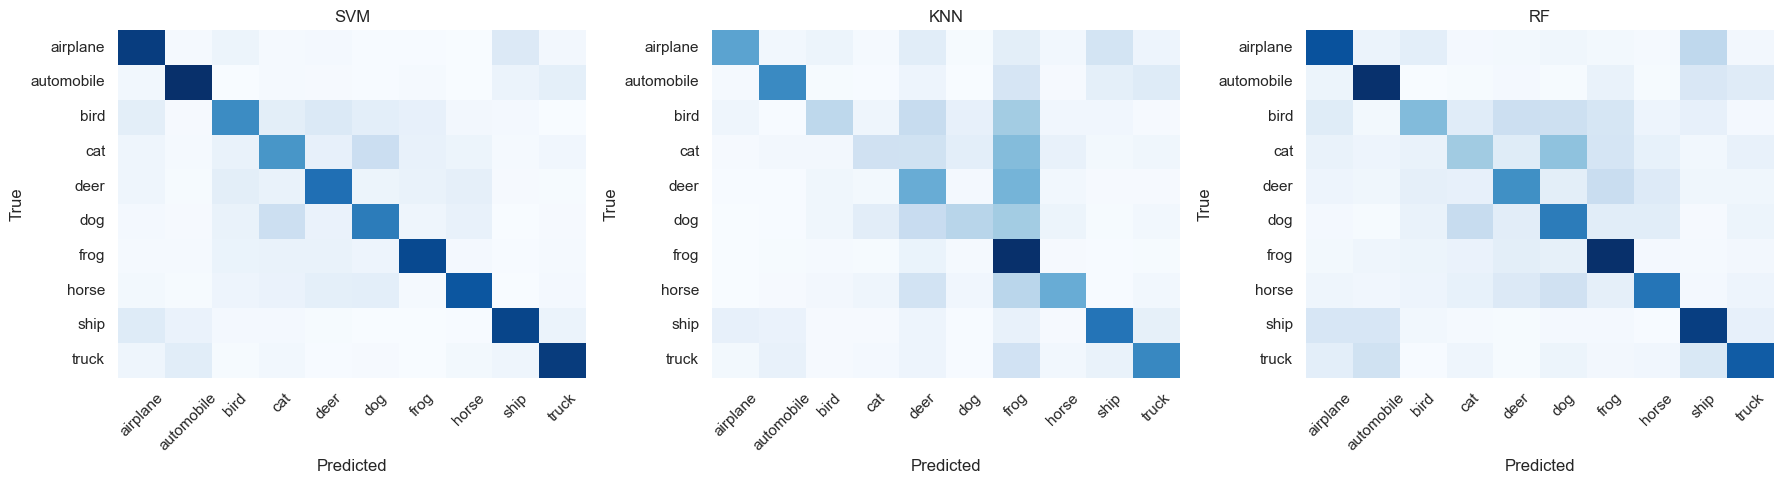

In [25]:
cms = {
    'SVM': confusion_matrix(y_test, y_pred_svm),
    'KNN': confusion_matrix(y_test, y_pred_knn),
    'RF': confusion_matrix(y_test, y_pred_rf),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, ax=ax, cmap='Blues', fmt='d', annot=False, cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


## 13) Comparative Analysis (Reference-style plots)

This section extends the baseline comparison with:
- normalized confusion matrices,
- macro and weighted metrics,
- per-class F1 heatmap,
- one-vs-rest ROC-AUC curves for multi-class CIFAR-10,
- a compact overall ranking score.


       Accuracy  F1 macro  Precision  Recall  Fit time (s)  Predict time (s)
Model                                                                       
SVM      0.6546    0.6538     0.6540  0.6546     1745.4231          199.7688
KNN      0.4617    0.4589     0.5227  0.4617        3.9814          396.5462
RF       0.4950    0.4885     0.4921  0.4950      103.3284            0.4560
Saved: cifar10_ml_classique_results.csv


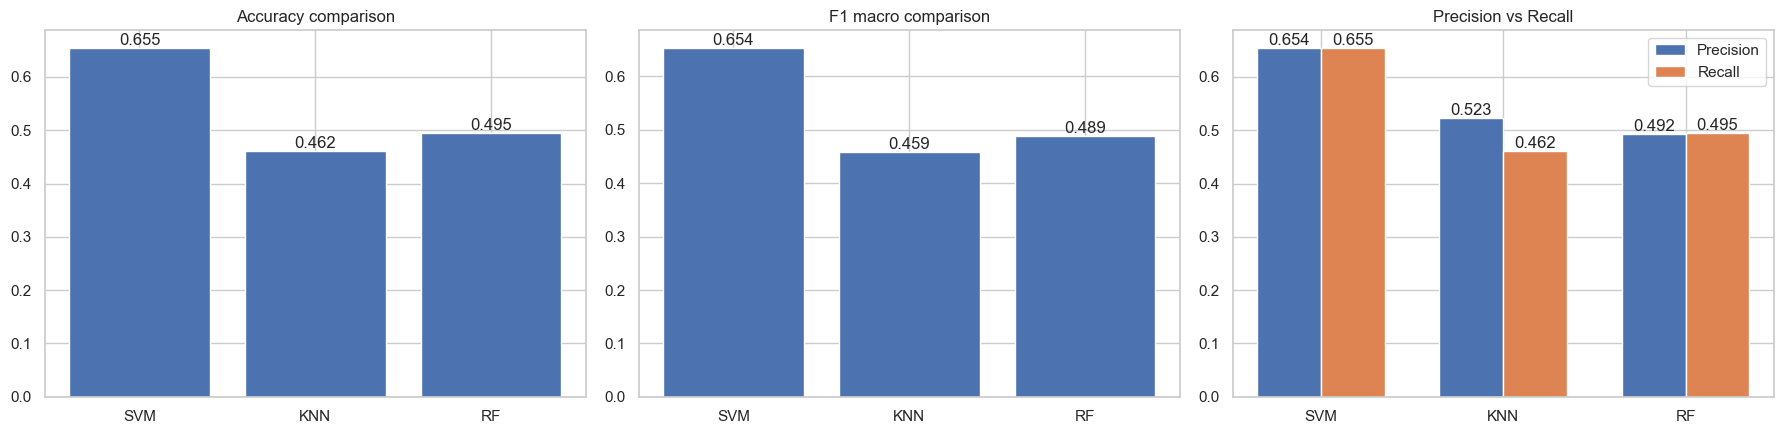

In [26]:
models = {
    'SVM': {
        'estimator': svm_final,
        'y_pred': y_pred_svm,
        'fit_t': svm_fit_time,
        'pred_t': svm_pred_time,
    },
    'KNN': {
        'estimator': knn_final,
        'y_pred': y_pred_knn,
        'fit_t': knn_fit_time,
        'pred_t': knn_pred_time,
    },
    'RF': {
        'estimator': rf_final,
        'y_pred': y_pred_rf,
        'fit_t': rf_fit_time,
        'pred_t': rf_pred_time,
    },
}

# Main summary table with macro + weighted variants.
rows = []
for name, payload in models.items():
    y_pred = payload['y_pred']
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 macro': f1_score(y_test, y_pred, average='macro'),
        'F1 weighted': f1_score(y_test, y_pred, average='weighted'),
        'Precision macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'Fit time (s)': payload['fit_t'],
        'Predict time (s)': payload['pred_t'],
    })

results_df = pd.DataFrame(rows).set_index('Model').sort_values('F1 macro', ascending=False)
print(results_df.round(4))
results_df.to_csv('cifar10_ml_classique_results.csv')
print('Saved: cifar10_ml_classique_results.csv')

# 1) Metrics bar charts (reference-style side-by-side comparison)
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
metric_cols = ['Accuracy', 'F1 macro', 'F1 weighted']
for ax, col in zip(axes, metric_cols):
    bars = ax.bar(results_df.index, results_df[col], color=sns.color_palette('Set2', n_colors=len(results_df)))
    ax.set_title(col)
    ax.set_ylim(0, 1)
    ax.bar_label(bars, fmt='%.3f')

axes[2].set_ylabel('Score')
plt.suptitle('Global Performance Comparison', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

# 2) Precision/Recall + computational cost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(results_df.index))
w = 0.35
bp = axes[0].bar(x - w / 2, results_df['Precision macro'], w, label='Precision macro')
br = axes[0].bar(x + w / 2, results_df['Recall macro'], w, label='Recall macro')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df.index)
axes[0].set_ylim(0, 1)
axes[0].set_title('Precision vs Recall (macro)')
axes[0].legend()
axes[0].bar_label(bp, fmt='%.3f')
axes[0].bar_label(br, fmt='%.3f')

cost_df = results_df[['Fit time (s)', 'Predict time (s)']]
cost_df.plot(kind='bar', ax=axes[1])
axes[1].set_title('Computational Cost Comparison')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# 3) Per-class F1 heatmap (who performs best per class)
per_class_f1 = {}
for name, payload in models.items():
    rep = classification_report(y_test, payload['y_pred'], target_names=class_names, output_dict=True, zero_division=0)
    per_class_f1[name] = {cls: rep[cls]['f1-score'] for cls in class_names}

f1_class_df = pd.DataFrame(per_class_f1).T
plt.figure(figsize=(12, 4.5))
sns.heatmap(f1_class_df, annot=True, fmt='.2f', cmap='YlGnBu', cbar=True)
plt.title('Per-class F1 Score Heatmap')
plt.xlabel('Class')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# 4) Normalized confusion matrices for easier qualitative comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (name, payload) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, payload['y_pred'], normalize='true')
    sns.heatmap(cm, ax=ax, cmap='Blues', vmin=0, vmax=1, cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{name} - Normalized CM')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 5) Multi-class ROC-AUC (one-vs-rest), similar to reference notebook
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

plt.figure(figsize=(9, 7))
for name, payload in models.items():
    est = payload['estimator']
    if hasattr(est, 'predict_proba'):
        y_score = est.predict_proba(X_test_pca)
    elif hasattr(est, 'decision_function'):
        y_score = est.decision_function(X_test_pca)
        if y_score.ndim == 1:
            y_score = y_score[:, None]
    else:
        continue

    auc_macro = roc_auc_score(y_test_bin, y_score, multi_class='ovr', average='macro')

    # Micro-average ROC curve
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    plt.plot(fpr_micro, tpr_micro, lw=2, label=f'{name} (macro AUC={auc_macro:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.title('One-vs-Rest ROC Curves (micro-average)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 6) Composite score to summarize trade-off between quality and speed
norm_fit = (results_df['Fit time (s)'] - results_df['Fit time (s)'].min()) / (results_df['Fit time (s)'].max() - results_df['Fit time (s)'].min() + 1e-9)
norm_pred = (results_df['Predict time (s)'] - results_df['Predict time (s)'].min()) / (results_df['Predict time (s)'].max() - results_df['Predict time (s)'].min() + 1e-9)
results_df['Composite score'] = 0.5 * results_df['F1 macro'] + 0.3 * results_df['Accuracy'] - 0.1 * norm_fit - 0.1 * norm_pred

ranked_df = results_df.sort_values('Composite score', ascending=False)
print('\nComposite ranking (higher is better):')
print(ranked_df[['Accuracy', 'F1 macro', 'Fit time (s)', 'Predict time (s)', 'Composite score']].round(4))

plt.figure(figsize=(8, 4.5))
bars = plt.bar(ranked_df.index, ranked_df['Composite score'], color=sns.color_palette('viridis', n_colors=len(ranked_df)))
plt.title('Overall Model Ranking (quality-speed trade-off)')
plt.ylabel('Composite score')
plt.bar_label(bars, fmt='%.3f')
plt.tight_layout()
plt.show()


## 14) Optional — Cross-Validation & Grid Search


In [28]:
run_optional_cv = True
if run_optional_cv:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    gs_svm = GridSearchCV(SVC(kernel='rbf', random_state=42), {'C': [1, 10, 100], 'gamma': ['scale', 0.01, 0.1]}, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
    gs_svm.fit(X_train_pca, y_train)
    print('SVM best params:', gs_svm.best_params_, '| CV score:', gs_svm.best_score_)

    gs_knn = GridSearchCV(KNeighborsClassifier(weights='distance', algorithm='ball_tree', metric='euclidean'), {'n_neighbors': [3, 5, 7, 11, 15]}, cv=cv, scoring='accuracy', n_jobs=-1)
    gs_knn.fit(X_train_pca, y_train)
    print('KNN best params:', gs_knn.best_params_, '| CV score:', gs_knn.best_score_)

    gs_rf = GridSearchCV(RandomForestClassifier(max_features='sqrt', oob_score=True, n_jobs=-1, random_state=42), {'n_estimators': [100, 200, 300], 'max_depth': [None, 20, 30]}, cv=cv, scoring='accuracy', n_jobs=-1)
    gs_rf.fit(X_train_pca, y_train)
    print('RF best params:', gs_rf.best_params_, '| CV score:', gs_rf.best_score_)
else:
    print('Optional section skipped. Set run_optional_cv=True to execute.')


Fitting 5 folds for each of 9 candidates, totalling 45 fits


KeyboardInterrupt: 